# Training a PPO racing agent

This notebook develops the project-owned clipped Proximal Policy Optimization agent. It uses the readable loop in `training/engines/ppo.py`, making fixed-rollout collection, GAE targets, seeded minibatches, and repeated optimization explicit.

The exact policy ratio, clipped loss, value target, and boundary conventions follow [`docs/LEARNING.md`](../docs/LEARNING.md). The environment and procedural circuits are specified in [`docs/MDP.md`](../docs/MDP.md) and [`docs/TRACK.md`](../docs/TRACK.md).

## Why move from A2C to PPO?

A2C reduces REINFORCE variance with a critic and GAE, but it performs only one update from each collected rollout. Reusing that rollout would improve data efficiency; after the first update, however, the current actor no longer matches the behaviour policy that sampled the actions. An unconstrained second update can therefore move too far using stale data.

PPO stores the behaviour-policy log-probability at collection time. During optimization it compares the current and behaviour policies through the importance ratio

\[
\omega_t(\theta)
= \exp\left(
\log\pi_\theta(A_t\mid O_t)
-\log\pi_{\theta_{\mathrm{old}}}(A_t\mid O_t)
\right).
\]

A ratio above one means the current actor makes the sampled action more likely; a ratio below one means it makes it less likely.

## Clipped sample reuse

PPO keeps A2C's detached GAE advantages and critic targets. For minibatch \(B\), the actor minimizes

\[
\mathcal L_{\mathrm{actor}}(\theta)
= -\frac{1}{|B|}\sum_{t\in B}
\min\left\{
\omega_t\widetilde{\mathbb A}_t,\,
\operatorname{clip}(\omega_t,1-\epsilon,1+\epsilon)
\widetilde{\mathbb A}_t
\right\}.
\]

The minimum chooses the pessimistic improvement estimate when the ratio leaves \([1-\epsilon,1+\epsilon]\). The critic still minimizes the unclipped half-squared error

\[
\mathcal L_{\mathrm{critic}}(w)
= \frac{1}{2|B|}\sum_{t\in B}
\left(v_w(O_t)-y_t\right)^2.
\]

Old log-probabilities, standardized advantages, and critic targets stay fixed while the rollout is reused for four seeded minibatch epochs.

Clipping bounds how far a *single* minibatch step may move the policy, but nothing bounds the drift accumulated across many reuses of the same rollout. Two mechanisms bound it here. Four epochs rather than ten is the first: under ten unconditional epochs a 2,000,000-interaction run repeatedly collapsed from a completed lap to near-zero return and relearned. The approximate KL is the second, and it is a control rather than only a diagnostic: after each complete epoch, if its mean exceeds the target `0.02` the update ends and the remaining epochs are skipped. The consequence is that the number of epochs actually run varies between updates, so it is recorded as `completed_epochs` alongside the configured maximum, and the optimizer cost of an update is data-dependent rather than fixed.

PPO usually gains sample efficiency over A2C, at the cost of more optimization per interaction and a biased clipped surrogate.

## Configuration

The primary stopping rule is `TRAINING_INTERACTION_BUDGET`. The same setting in REINFORCE, A2C, and PPO gives each algorithm an equal number of environment transitions even though their episode and optimizer-update counts differ.

Set `TRAIN_ON_RANDOM_CIRCUITS = True` to generate a fresh procedural circuit for every logical training episode. The root-and-episode mapping is shared across algorithms and independent of worker completion order. Rendering and greedy evaluation use a fixed reference circuit.

The initial dashboard shows 20 actions; the final dashboard permits the full 1,000-step environment limit.

In [1]:
import sys
import warnings
from dataclasses import asdict, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API.*",
    category=UserWarning,
    module="pygame.pkgdata",
)

from agents import PPOAgent
from configs import (
    FIXED_CRITIC_CONFIG,
    MEDIUM_ACTOR_CONFIG,
    EnvironmentConfig,
    ExecutionConfig,
    ObservationNormalizationConfig,
    physical_cpu_count,
    StartStateConfig,
    PPOConfig,
)
from envs.racing import RacingEnv
from envs.tracks import TrackWithGeometry
from recording import RunCategory
from training.educational_visualization import (
    plot_algorithm_diagnostics,
    plot_driving_behavior,
    plot_optimization_and_exploration,
    plot_outcomes_and_lap_time,
    plot_progress_and_efficiency,
    plot_task_performance,
    watch_deterministic_rollout,
)
from training.engines.ppo import PPOTrainingEngine
from training.evaluation import evaluate_deterministic
from training.normalization import RunningObservationNormalizer
from utils.random import (
    RunSeedStreams,
    SeedNamespace,
    SeedStream,
    configure_torch_determinism,
)

# Reproducibility and execution
ROOT_SEED = 0
TRAINING_INTERACTION_BUDGET = 2_000_000
NUM_ENVS = physical_cpu_count()

# Circuit schedule
TRAIN_ON_RANDOM_CIRCUITS = False
SINGLE_CIRCUIT_SEED = 0

# Actor, critic, and PPO
ACTOR_CONFIG = replace(MEDIUM_ACTOR_CONFIG, learning_rate=3e-4)
CRITIC_LEARNING_RATE = 1e-3
PPO_CONFIG = PPOConfig(
    discount=0.9995,
    gae_lambda=0.95,
    transitions_per_rollout=2_048,
    optimization_epochs=4,
    minibatch_size=64,
    clip_epsilon=0.2,
)
ENVIRONMENT_CONFIG = EnvironmentConfig()
# Training samples a start pose all around the circuit for state coverage, but
# every greedy evaluation launches from the canonical start line so that the
# reported number always answers the same question and is exactly reproducible.
EVALUATION_CONFIG = replace(
    ENVIRONMENT_CONFIG, start=StartStateConfig(randomized=False)
)
NORMALIZATION_CONFIG = ObservationNormalizationConfig()

# Greedy evaluation and plots
EVALUATION_INTERVAL_INTERACTIONS = 50_000
EVALUATION_EPISODES = 1
MOVING_AVERAGE_WINDOW = 20

# Live rollout dashboard
RENDER_RESET_SEED = 123
VIEWER_MODE = "inline"
INITIAL_RENDER_STEPS = 20
FINAL_RENDER_STEPS = ENVIRONMENT_CONFIG.simulation.max_episode_steps
LIVE_FRAME_DELAY = 0.01


True

## Build the reference circuit, random streams, actor, critic, and engine

PPO adds one independent stream for seeded minibatch order. The actor, critic, policy sampling, environment resets, circuit generation, optimization order, and greedy evaluation therefore remain reproducible without consuming one another's random state.

In [2]:
execution_config = ExecutionConfig(environment_workers=NUM_ENVS)
configure_torch_determinism(execution_config)
streams = RunSeedStreams(SeedNamespace.MULTI_CIRCUIT_DEVELOPMENT, ROOT_SEED)
track_streams = RunSeedStreams(
    SeedNamespace.EXPERIMENT_2_TRAINING_TRACK,
    ROOT_SEED,
)

reference_track = TrackWithGeometry.generate(
    SINGLE_CIRCUIT_SEED,
    track_config=ENVIRONMENT_CONFIG.track,
    vehicle_config=ENVIRONMENT_CONFIG.vehicle,
)
tracks = (reference_track,)


def training_track_seed(episode_index):
    generator = track_streams.get_numpy_generator(
        SeedStream.TRACK_GENERATION,
        substream_identity=episode_index,
    )
    return int(generator.integers(0, 2**32, dtype=np.uint32))


probe_environment = RacingEnv(reference_track, config=ENVIRONMENT_CONFIG)
observation_dimensions = probe_environment.observation_space.shape[0]
probe_environment.close()

agent = PPOAgent(
    observation_dimensions=observation_dimensions,
    actor_config=ACTOR_CONFIG,
    critic_config=FIXED_CRITIC_CONFIG,
    config=PPO_CONFIG,
    critic_learning_rate=CRITIC_LEARNING_RATE,
    actor_initialization_generator=streams.get_torch_generator(
        SeedStream.ACTOR_INITIALIZATION,
    ),
    critic_initialization_generator=streams.get_torch_generator(
        SeedStream.CRITIC_INITIALIZATION,
    ),
    sampling_generator=tuple(
        streams.get_torch_generator(
            SeedStream.POLICY_ACTION_SAMPLING,
                substream_identity=index,
        )
        for index in range(NUM_ENVS)
    ),
    optimization_generator=streams.get_torch_generator(
        SeedStream.OPTIMIZATION_BATCH_ORDER,
    ),
)
normalizer = RunningObservationNormalizer(
    observation_dimensions,
    NORMALIZATION_CONFIG,
)
engine = PPOTrainingEngine(
    agent=agent,
    tracks=tracks,
    environment_config=ENVIRONMENT_CONFIG,
    normalizer=normalizer,
    environment_reset_generator=tuple(
        streams.get_numpy_generator(
            SeedStream.ENVIRONMENT_RESETS,
            substream_identity=index,
        )
        for index in range(NUM_ENVS)
    ),
    track_selection_generator=tuple(
        streams.get_numpy_generator(
            SeedStream.TRAINING_TRACK_SELECTION,
            substream_identity=index,
        )
        for index in range(NUM_ENVS)
    ),
    track_seed_for_episode=(training_track_seed if TRAIN_ON_RANDOM_CIRCUITS else None),
    execution_config=execution_config,
)
evaluation_generator = streams.get_numpy_generator(SeedStream.EVALUATION)

training_mode = (
    "fresh procedural circuit per episode"
    if TRAIN_ON_RANDOM_CIRCUITS
    else f"fixed circuit seed {SINGLE_CIRCUIT_SEED}"
)
print(f"Training mode: {training_mode}")
print(f"Interaction budget: {TRAINING_INTERACTION_BUDGET:,}")
print(f"Actor parameters: {agent.actor_parameter_count:,}")
print(f"Critic parameters: {agent.critic_parameter_count:,}")

Training mode: fixed circuit seed 0
Interaction budget: 2,000,000
Actor parameters: 4,676
Critic parameters: 4,609


## Policy before training

The initial dashboard uses deterministic bounded mean actions and frozen normalization. It shows the fixed reference circuit beside current progress, return, speed, throttle, steering, and the evolving speed/control traces.

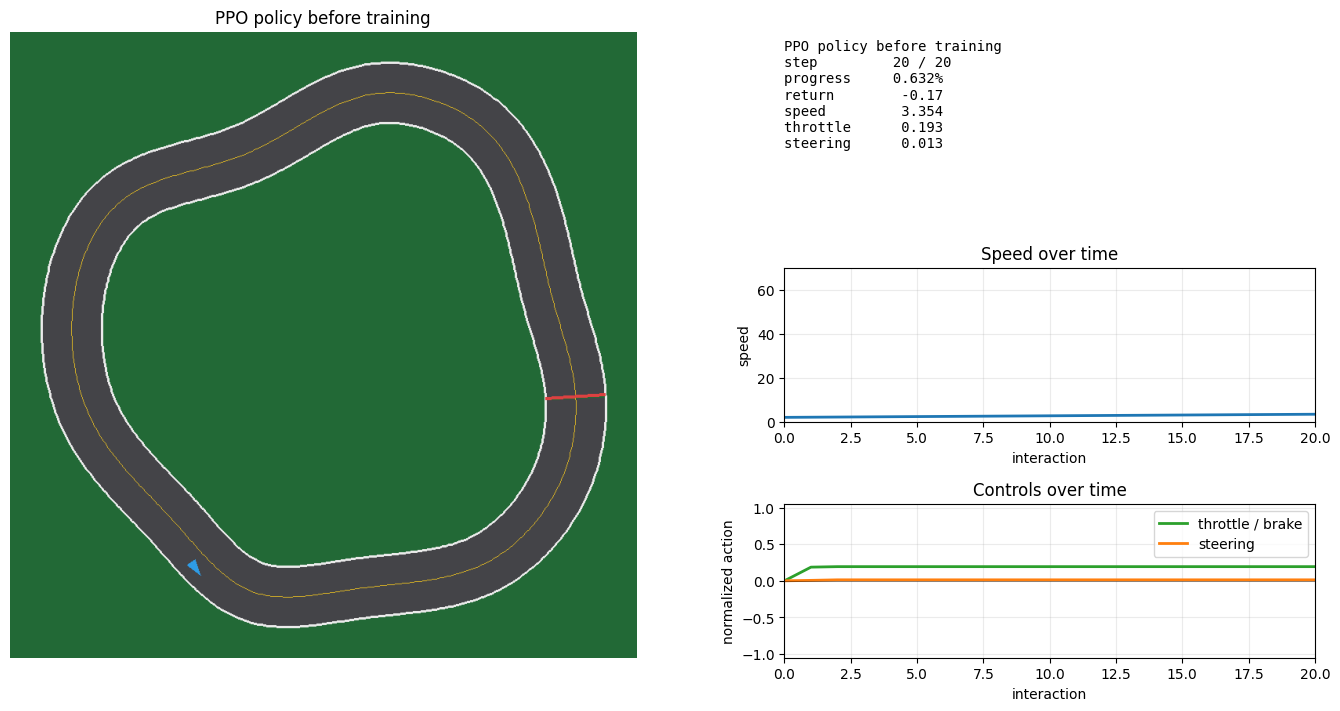

{'interactions': 20,
 'return': -0.1684696036916702,
 'collision': False,
 'lap_completed': False,
 'progress': 0.006315303963083298,
 'final_speed': 3.3544843196868896,
 'final_throttle': 0.19328074157238007,
 'final_steering': 0.013289298862218857}

In [3]:
initial_rollout = watch_deterministic_rollout(
    "PPO policy before training",
    reference_track,
    agent,
    normalizer,
    ENVIRONMENT_CONFIG,
    max_steps=INITIAL_RENDER_STEPS,
    reset_seed=RENDER_RESET_SEED,
    viewer_mode=VIEWER_MODE,
    frame_delay=LIVE_FRAME_DELAY,
)
initial_rollout

## Scheduled greedy evaluation

Each checkpoint aggregates `EVALUATION_EPISODES` deterministic episodes. The return and maximum-progress means retain plus/minus one population standard deviation. The fixed reference circuit is deterministic, so this band is normally zero today; the aggregation remains ready for varied fixed evaluation circuits or randomized starts.

In [4]:
evaluation_rows = []
evaluation_state = {
    "interactions": 0,
    "episodes": 0,
    "next_boundary": EVALUATION_INTERVAL_INTERACTIONS,
}


def run_greedy_evaluation(completed_training_episodes, training_interactions):
    returns = []
    progress_values = []
    lap_times = []
    outcomes = []
    for _ in range(EVALUATION_EPISODES):
        result = evaluate_deterministic(
            lambda: RacingEnv(reference_track, config=EVALUATION_CONFIG),
            agent,
            normalizer,
            run_category=RunCategory.REDUCED_VALIDATION,
            evaluation_index=evaluation_state["episodes"],
            training_interactions=training_interactions,
            evaluation_interactions_before=evaluation_state["interactions"],
            reset_seed=int(evaluation_generator.integers(0, 2**32, dtype=np.uint32)),
            root_identity=ROOT_SEED,
            circuit_identity=str(reference_track.track.generation.seed),
        )
        episode = result.record.episode
        evaluation_state["episodes"] += 1
        evaluation_state["interactions"] = result.record.evaluation_interactions
        returns.append(episode.undiscounted_return)
        progress_values.append(episode.maximum_progress)
        outcomes.append(episode.outcome.value)
        if episode.lap_time is not None:
            lap_times.append(episode.lap_time)

    evaluation_rows.append(
        {
            "completed_training_episodes": completed_training_episodes,
            "training_interactions": training_interactions,
            "return_mean": float(np.mean(returns)),
            "return_standard_deviation": float(np.std(returns)),
            "maximum_progress_mean": float(np.mean(progress_values)),
            "maximum_progress_standard_deviation": float(np.std(progress_values)),
            "lap_time_mean": float(np.mean(lap_times)) if lap_times else None,
            "completed_fraction": float(
                np.mean([outcome == "completed" for outcome in outcomes])
            ),
            "outcomes": outcomes,
        }
    )


def evaluate_on_schedule(episode_record, current_history):
    del episode_record
    while current_history.training_interactions >= evaluation_state["next_boundary"]:
        run_greedy_evaluation(
            len(current_history.episodes),
            current_history.training_interactions,
        )
        evaluation_state["next_boundary"] += EVALUATION_INTERVAL_INTERACTIONS


run_greedy_evaluation(0, 0)
evaluation_rows[-1]

{'completed_training_episodes': 0,
 'training_interactions': 0,
 'return_mean': 0.8937394392196749,
 'return_standard_deviation': 0.0,
 'maximum_progress_mean': 0.12941999395982753,
 'maximum_progress_standard_deviation': 0.0,
 'lap_time_mean': None,
 'completed_fraction': 0.0,
 'outcomes': ['crashed']}

## Train to the common interaction budget

The workers fill a pooled 2,048-transition rollout without mixing GAE recursion between environment columns. PPO then freezes the rollout targets and old log-probabilities for every minibatch epoch it runs. At the exact interaction boundary, the final short rollout is still optimized, so the algorithm neither overshoots the budget nor throws away valid data.

In [5]:
try:
    history = engine.train(
        TRAINING_INTERACTION_BUDGET,
        on_episode_end=evaluate_on_schedule,
    )
finally:
    engine.close()

if evaluation_rows[-1]["training_interactions"] != history.training_interactions:
    run_greedy_evaluation(
        len(history.episodes),
        history.training_interactions,
    )

print(f"Episodes completed: {len(history.episodes):,}")
print(f"Training interactions: {history.training_interactions:,}")
print(f"Optimizer updates: {len(history.updates):,}")
print(f"Greedy evaluation checkpoints: {len(evaluation_rows):,}")

Training interactions:   0%|          | 0/2000000 [00:00<?, ?interaction/s]

Episodes completed: 5,155
Training interactions: 2,000,000
Optimizer updates: 977
Greedy evaluation checkpoints: 41


## Prepare the recorded data

PPO exposes the same episode and common optimization fields as A2C. Its update diagnostics additionally retain the importance-ratio distribution, approximate KL, and clip fraction produced by repeated sample reuse.

In [6]:
episode_rows = []
for record in history.episodes:
    row = asdict(record)
    row["outcome"] = record.outcome.value
    episode_rows.append(row)
update_rows = [asdict(record) for record in history.updates]

print("Last training episode:")
print(episode_rows[-1] if episode_rows else "No episode ended within the budget.")
print("\nLast optimizer update:")
print(update_rows[-1])
print("\nLast greedy evaluation:")
print(evaluation_rows[-1])

Last training episode:
{'episode_index': 5154, 'circuit_identity': '0', 'interactions': 393, 'undiscounted_return': 244.8403882589348, 'outcome': 'completed', 'final_progress': 1.000165601366846, 'maximum_progress': 1.000165601366846, 'mean_speed': 18.989417788333263, 'mean_throttle': 0.39208971041624385, 'mean_throttle_magnitude': 0.7751979379750001, 'lap_time': 15.72}

Last optimizer update:
{'update_index': 976, 'final_episode_index': 5164, 'training_interactions': 2000000, 'transition_count': 1152, 'diagnostics': {'actor_loss': -0.01777914786297414, 'critic_loss': 19.15052013264762, 'actor_gradient_norm': 1.1728446662425995, 'critic_gradient_norm': 6.328150994578997, 'actor_weight_norm': 23.556978225708008, 'critic_weight_norm': 60.261138916015625, 'actor_update_norm': 0.37478330731391907, 'critic_update_norm': 0.6705312728881836, 'actor_learning_rate': 0.0003, 'critic_learning_rate': 0.001, 'entropy_proxy': -3.916764259338379, 'explained_variance': 0.0015270113945007324, 'approxim

## Task performance

Training return includes Gaussian exploration, while greedy return measures the deterministic bounded mean policy. The evaluation uncertainty is shown explicitly rather than plotting individual evaluation episodes as if they were separate checkpoints.

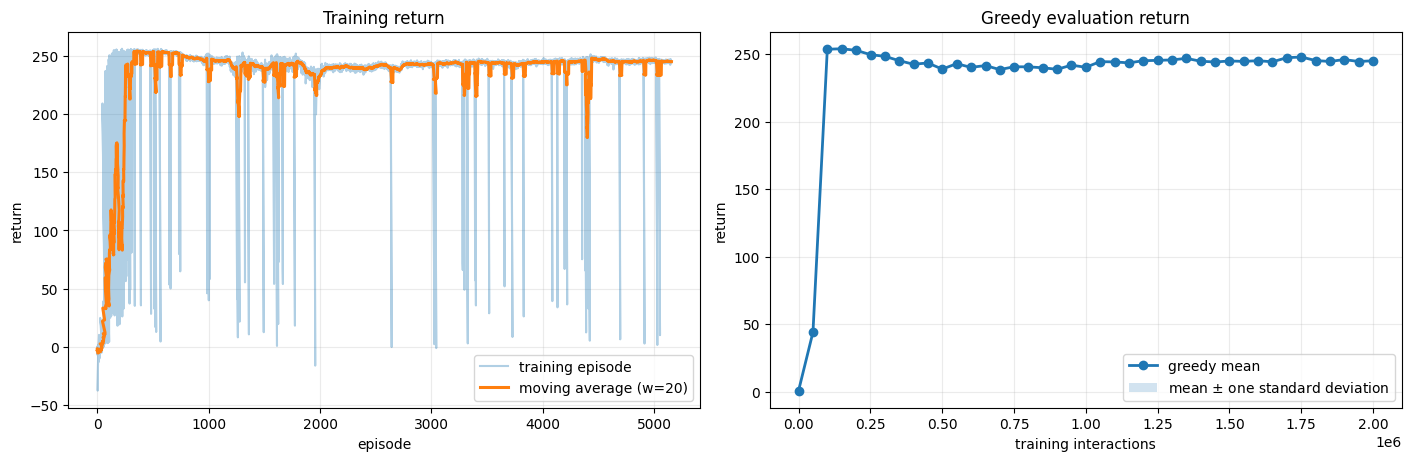

In [7]:
plot_task_performance(
    episode_rows,
    evaluation_rows,
    moving_average_window=MOVING_AVERAGE_WINDOW,
)
plt.show()

## Progress and sample efficiency

Maximum progress is shown for both the stochastic training behaviour and greedy evaluations, with separate moving averages. Episode length shows the interaction cost of each completed training episode.

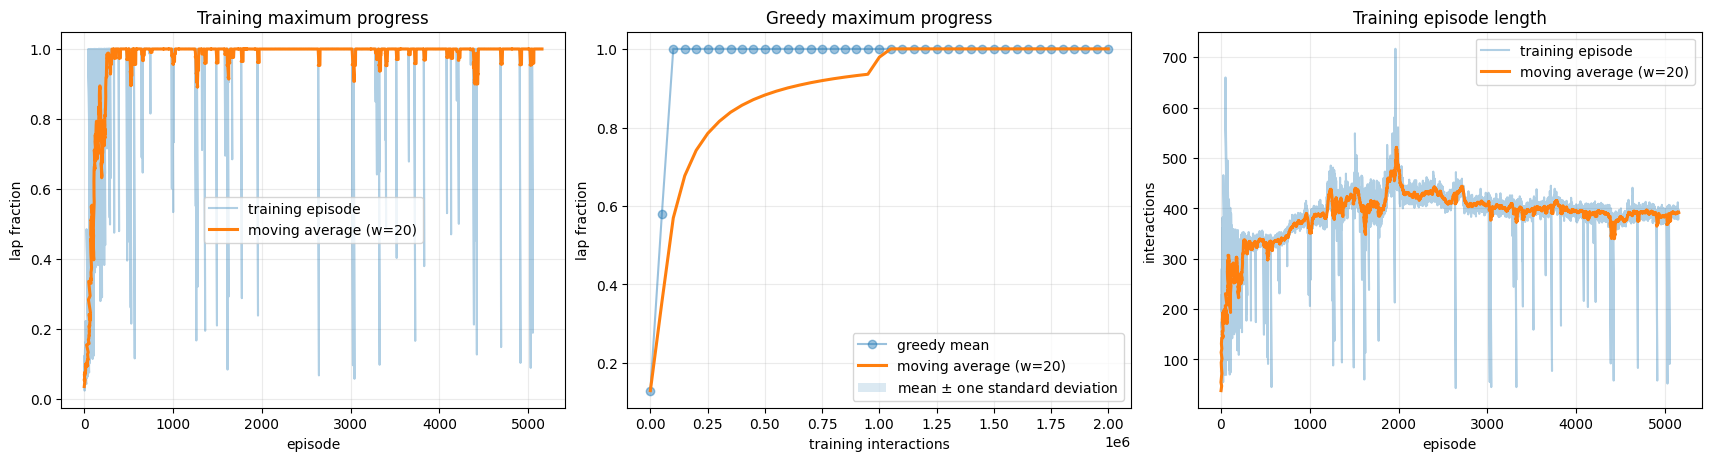

In [8]:
plot_progress_and_efficiency(
    episode_rows,
    evaluation_rows,
    moving_average_window=MOVING_AVERAGE_WINDOW,
)
plt.show()

## Driving behaviour

Mean speed and mean throttle magnitude reveal whether return improvements correspond to actual driving rather than stalling, coasting, or saturating longitudinal control.

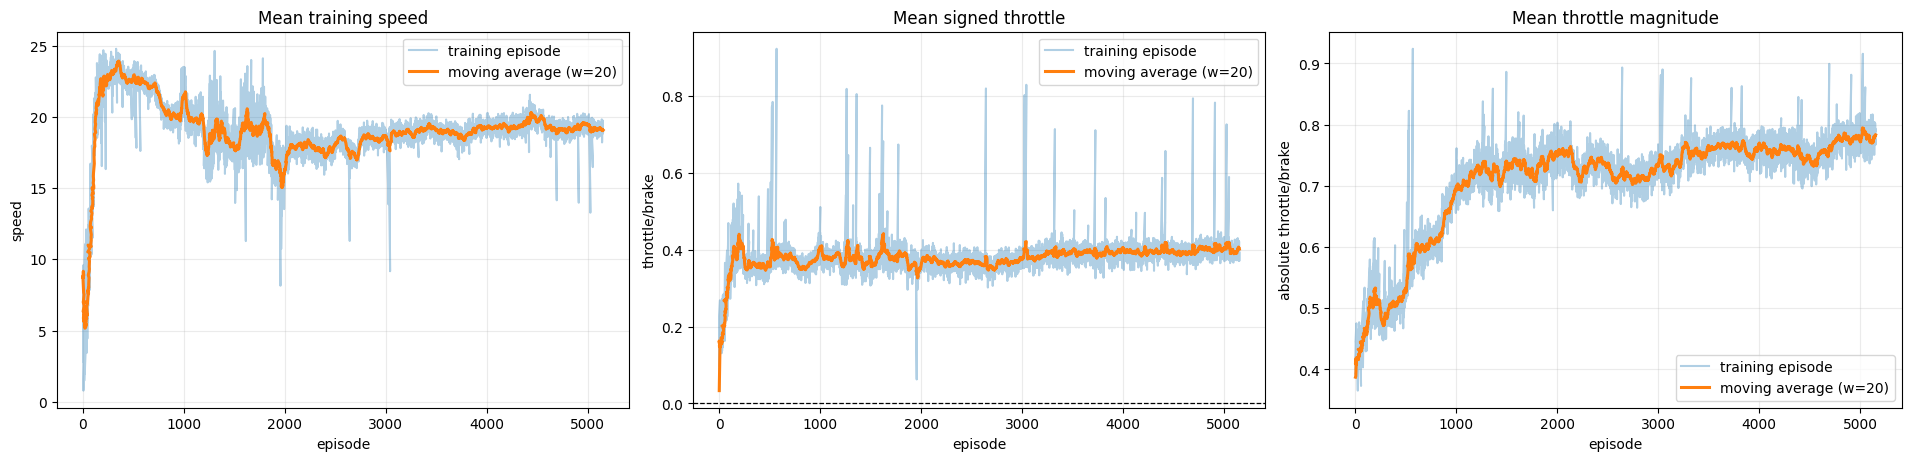

In [9]:
plot_driving_behavior(
    episode_rows,
    moving_average_window=MOVING_AVERAGE_WINDOW,
)
plt.show()

## Outcomes and lap time

Return alone cannot say *why* a policy scores what it scores. The outcome mix separates crashing from idling from lapping, and lap time is the racing objective the return only summarizes.


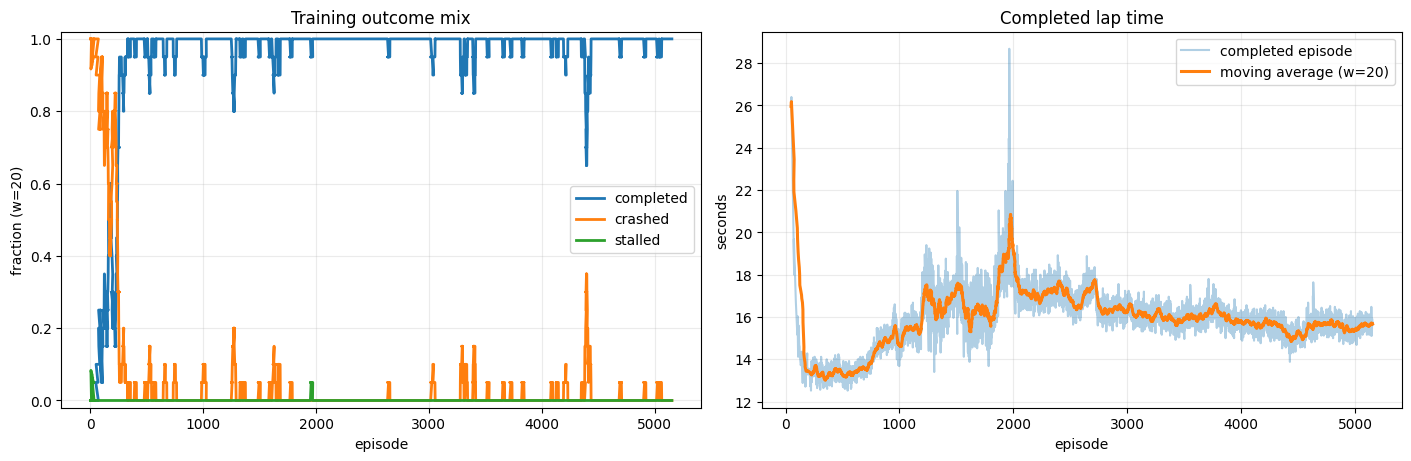

In [10]:
plot_outcomes_and_lap_time(
    episode_rows,
    moving_average_window=MOVING_AVERAGE_WINDOW,
)
plt.show()

## Optimization and learned exploration

Actor and critic losses are shown separately with moving averages. Their weight norms share a panel. Learned throttle and steering sigma are the exploration trace; PPO has no additional forced exploration-decay schedule.

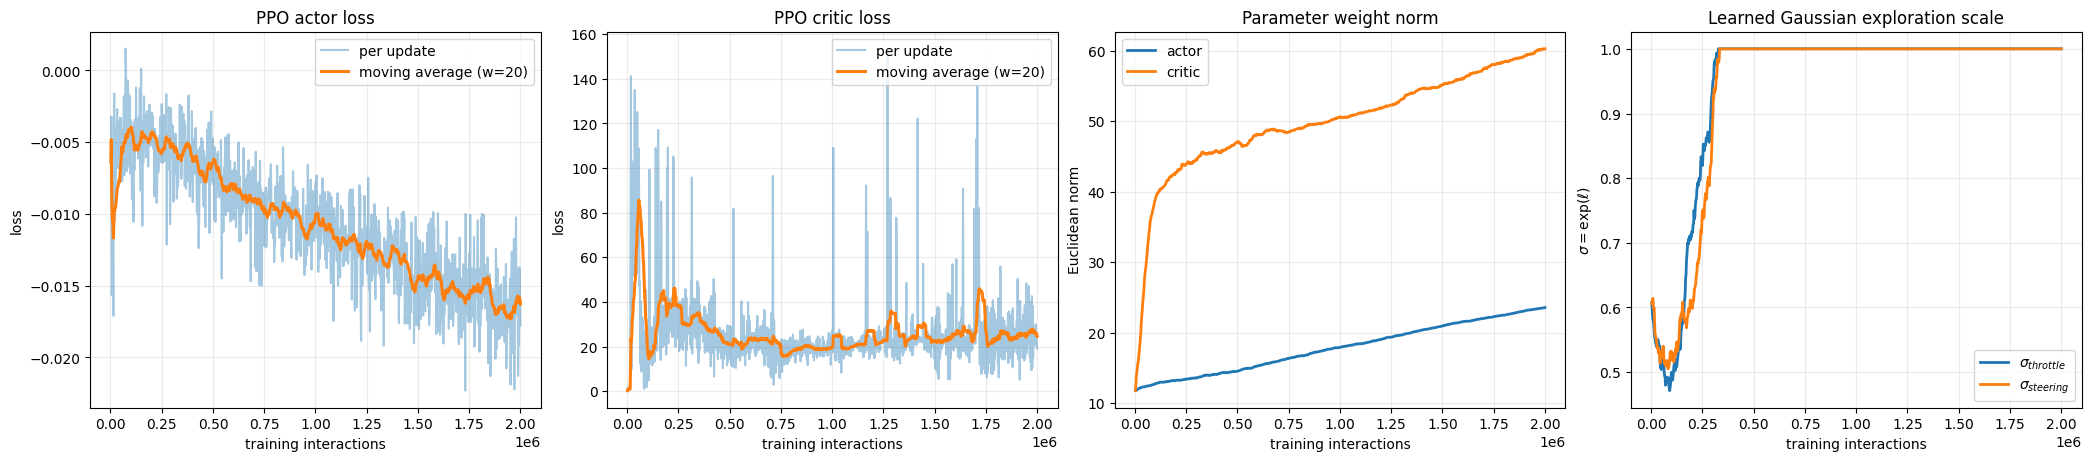

In [11]:
plot_optimization_and_exploration(
    update_rows,
    algorithm_name="PPO",
    moving_average_window=MOVING_AVERAGE_WINDOW,
    include_critic=True,
)
plt.show()

## PPO-specific diagnostics

Approximate KL estimates actor displacement from the behaviour policy, clip fraction shows how often the surrogate activates its bound, and explained variance tracks critic fit. They remain diagnostics only and do not change the configured update.

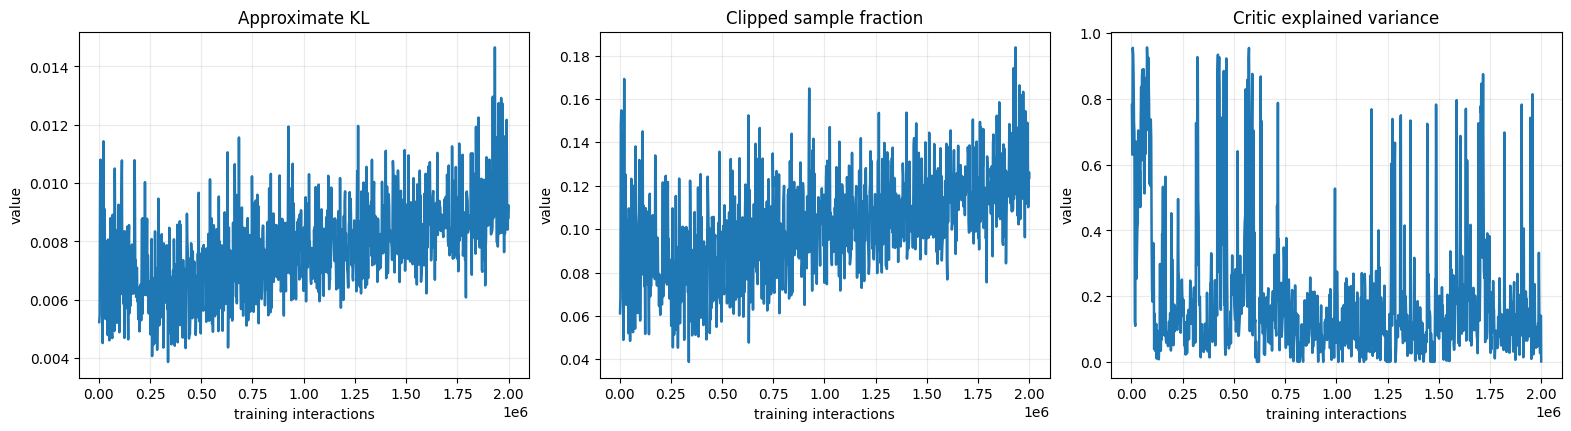

In [12]:
plot_algorithm_diagnostics(
    update_rows,
    algorithm_name="PPO",
)
plt.show()

## Policy after training

The final dashboard reuses the initial fixed circuit, reset seed, deterministic rule, and normalizer, but allows all 1,000 actions so a completed lap can be observed.

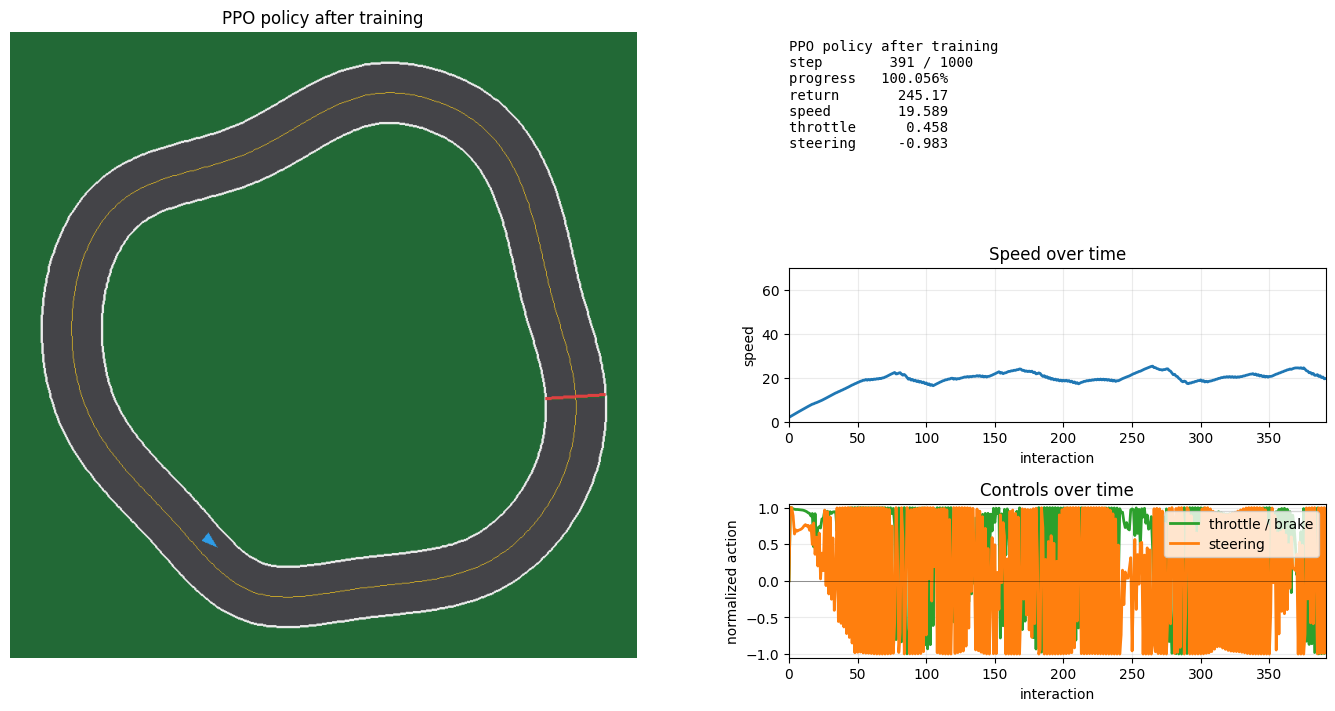

Before training: {'interactions': 20, 'return': -0.1684696036916702, 'collision': False, 'lap_completed': False, 'progress': 0.006315303963083298, 'final_speed': 3.3544843196868896, 'final_throttle': 0.19328074157238007, 'final_steering': 0.013289298862218857}
After training:  {'interactions': 391, 'return': 245.1694684784045, 'collision': False, 'lap_completed': True, 'progress': 1.000556797489471, 'final_speed': 19.58867073059082, 'final_throttle': 0.45774903893470764, 'final_steering': -0.9825887084007263}


: 

In [ ]:
final_rollout = watch_deterministic_rollout(
    "PPO policy after training",
    reference_track,
    agent,
    normalizer,
    ENVIRONMENT_CONFIG,
    max_steps=FINAL_RENDER_STEPS,
    reset_seed=RENDER_RESET_SEED,
    viewer_mode=VIEWER_MODE,
    frame_delay=LIVE_FRAME_DELAY,
)
print("Before training:", initial_rollout)
print("After training: ", final_rollout)